# Filters and Edges

This notebook contains code tests and visualizations for filtering and edge operations.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import sys
sys.path.append('../src')
from basic_operations import to_grayscale, adjust_gamma, adjust_logarithmic
from filters import mean_filter, gaussian_filter, sharpen_filter, custom_filter
from edge_detection import roberts_cross, sobel_operator

## Tests

In [6]:
# Wczytanie obrazu
img_pil = Image.open("../data/ptak_dudek.jpg")
img_rgb = np.array(img_pil)
img_gray = to_grayscale(img_rgb)

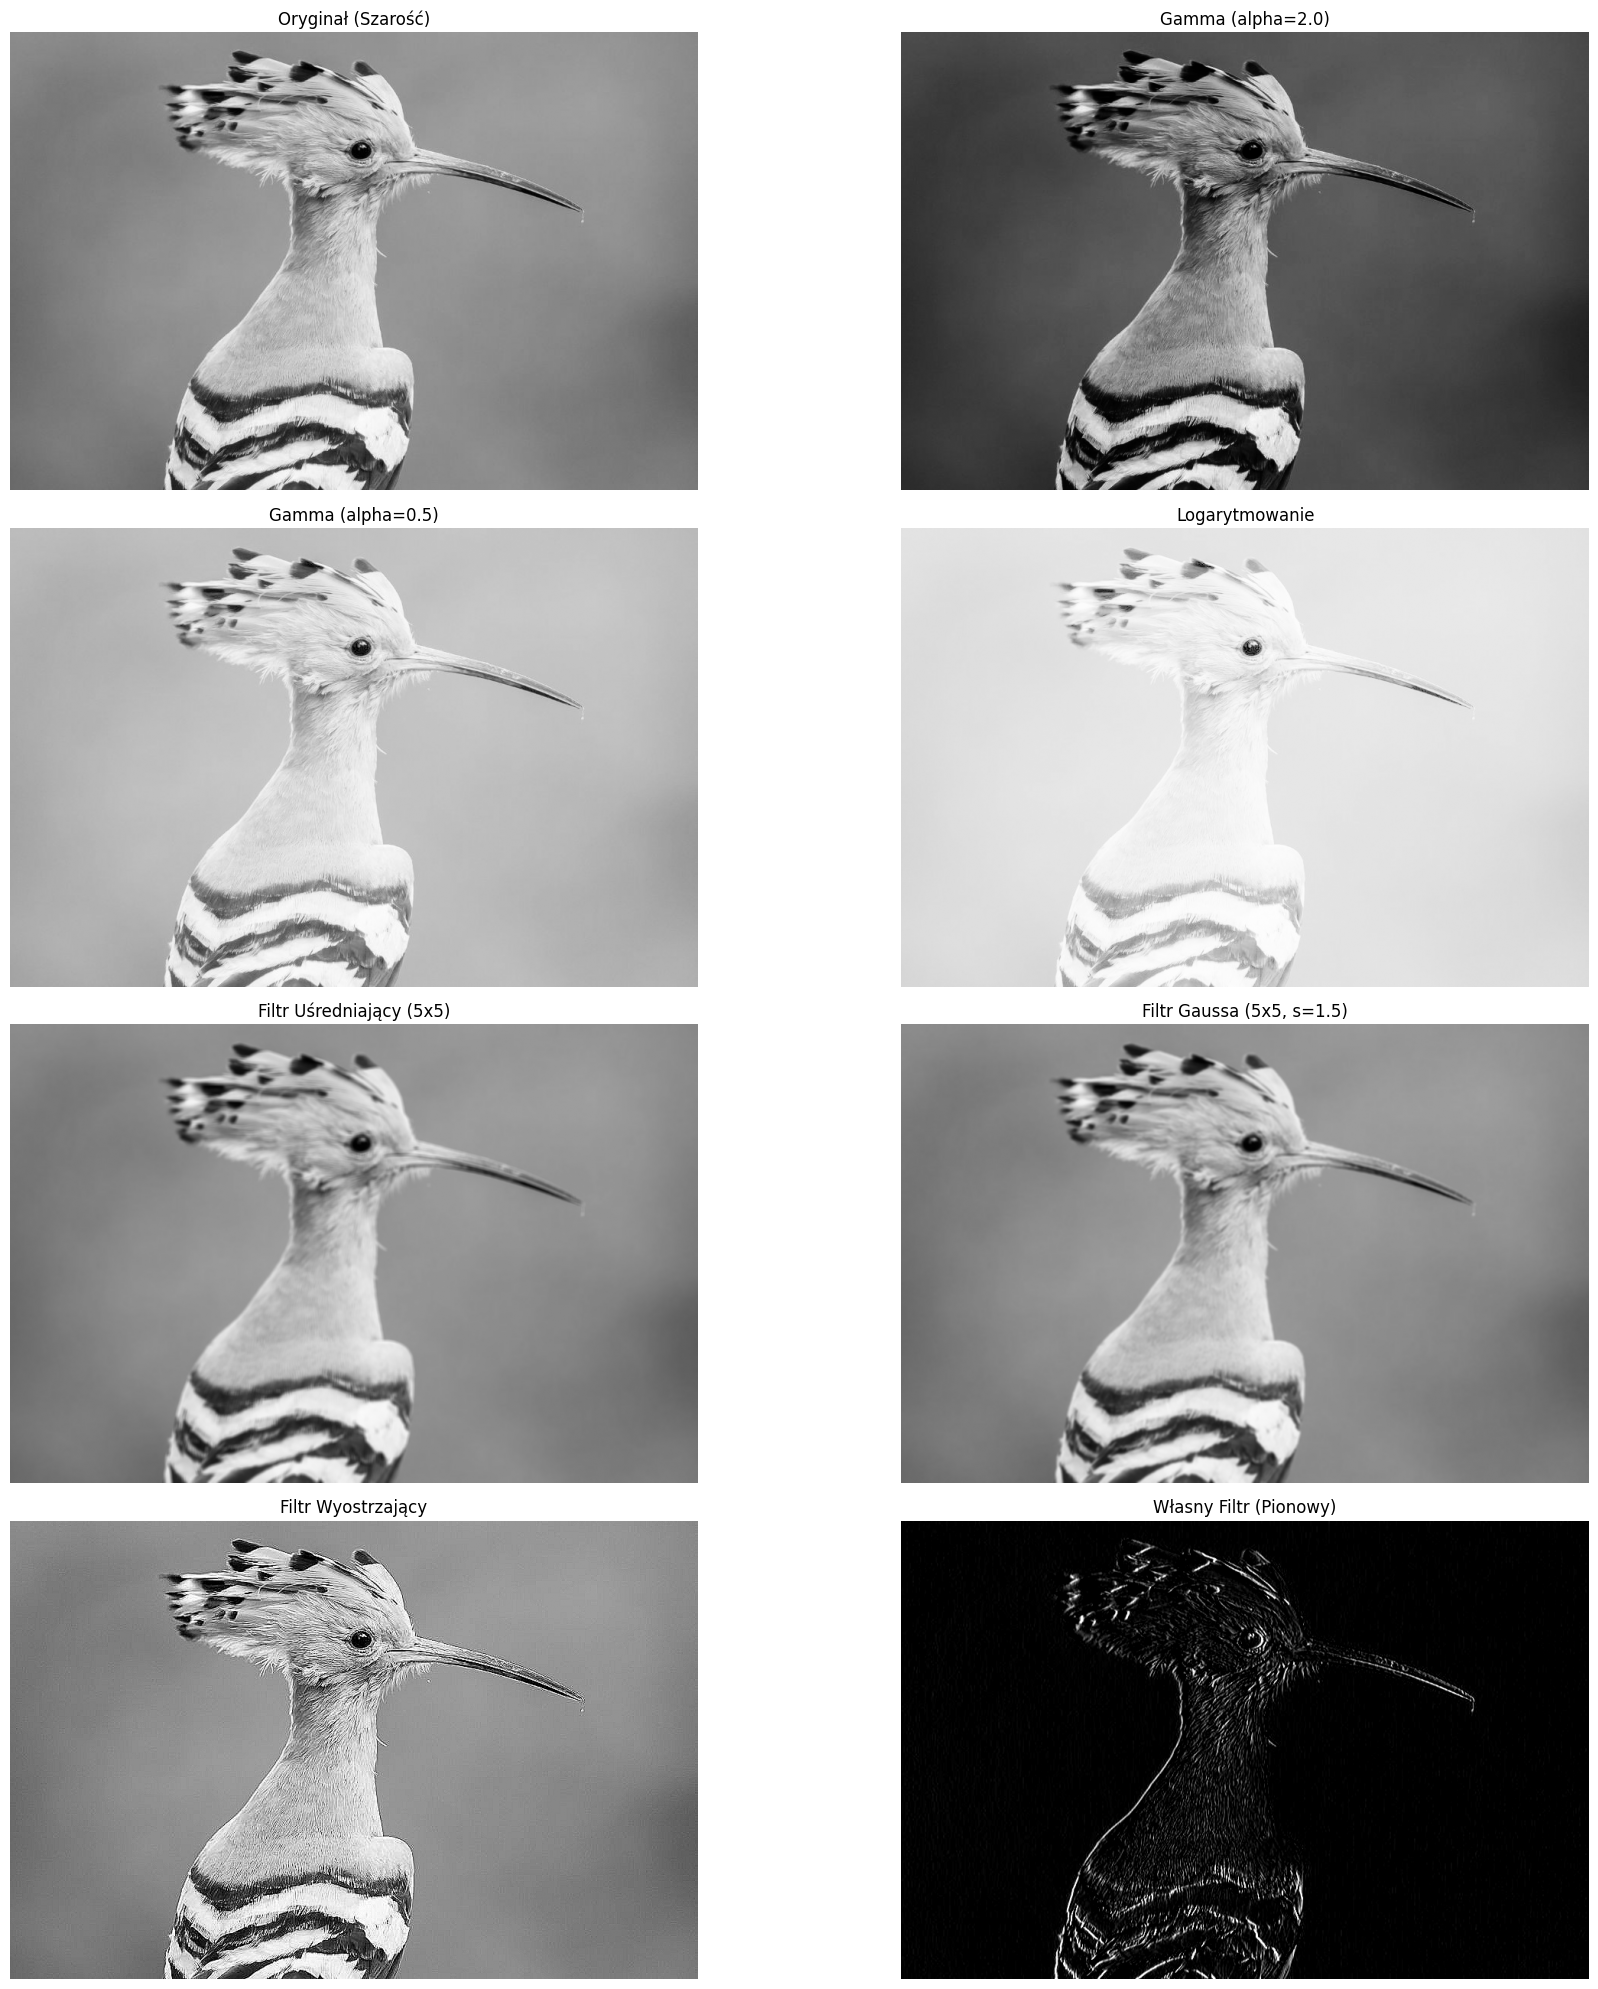

In [9]:
# Nowe operacje kontrastu
img_gamma_dark = adjust_gamma(img_gray, alpha=2.0)
img_gamma_bright = adjust_gamma(img_gray, alpha=0.5)
img_log = adjust_logarithmic(img_gray)

# Filtry
img_mean = mean_filter(img_gray, kernel_size=5)
img_gauss = gaussian_filter(img_gray, kernel_size=5, sigma=1.5)
img_sharpen = sharpen_filter(img_gray, strength=1.5)

# Przykładowy filtr własny (detekcja krawędzi pionowych)
custom_kernel = np.array([[-1, 0, 1], 
                          [-2, 0, 2], 
                          [-1, 0, 1]])
img_custom = custom_filter(img_gray, custom_kernel)

# Wyniki
fig, axes = plt.subplots(4, 2, figsize=(20, 20))
ax = axes.ravel()

images = {
    "Oryginał (Szarość)": img_gray,
    "Gamma (alpha=2.0)": img_gamma_dark,
    "Gamma (alpha=0.5)": img_gamma_bright,
    "Logarytmowanie": img_log,
    "Filtr Uśredniający (5x5)": img_mean,
    "Filtr Gaussa (5x5, s=1.5)": img_gauss,
    "Filtr Wyostrzający": img_sharpen,
    "Własny Filtr (Pionowy)": img_custom
}

for i, (title, img) in enumerate(images.items()):
    ax[i].imshow(img, cmap='gray', vmin=0, vmax=255)
    ax[i].set_title(title)
    ax[i].axis('off')

plt.tight_layout()
plt.show()

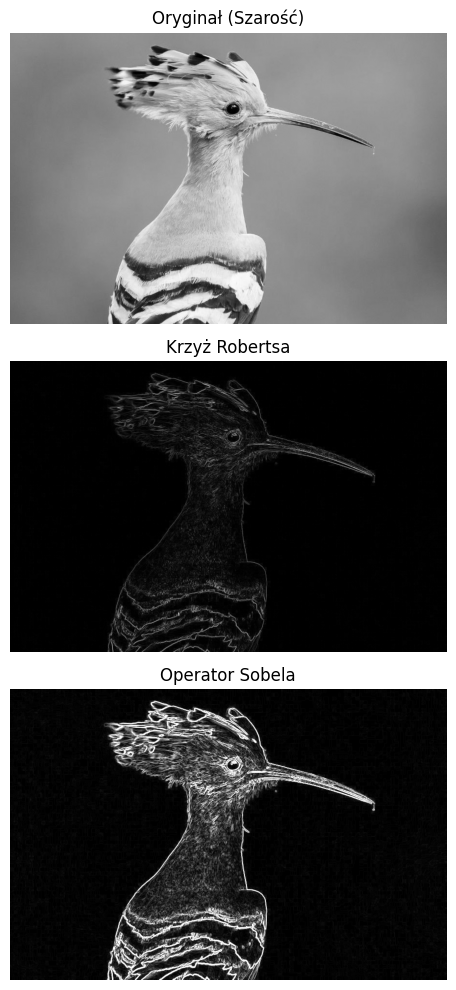

In [13]:
# Wykrywanie krawędzi
img_roberts = roberts_cross(img_gray)
img_sobel = sobel_operator(img_gray)

# Wyświetlanie
fig, axes = plt.subplots(3, 1, figsize=(5, 10))
ax = axes.ravel()

images = {"Oryginał (Szarość)": img_gray, "Krzyż Robertsa": img_roberts, "Operator Sobela": img_sobel}

for i, (title, img) in enumerate(images.items()):
    ax[i].imshow(img, cmap='gray', vmin=0, vmax=255)
    ax[i].set_title(title)
    ax[i].axis('off')

plt.tight_layout()
plt.show()